# Indian Railway Predictive Maintenance EDA

In [ ]:
# 1. Data Loading & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/indian_railway_predictive_maintenance_100k.csv", engine ='python',on_bad_lines ='skip')

In [ ]:
print(df.isnull().sum())

train_id                      0
region                        0
season                        0
train_type                    0
train_age_years               0
average_speed_kmph            0
distance_travelled_km         0
track_temperature_c           0
rail_wear_mm                  0
track_vibration_level      6020
ballast_condition             0
track_curvature_degree        0
ambient_temperature_c         0
humidity_percent           5008
rainfall_mm                8020
wind_speed_kmph            7010
wheel_wear_percent         3012
axle_temperature_c         6014
brake_pressure_psi            0
brake_pad_wear_percent     4011
bearing_temperature_c      7024
battery_voltage            4011
traction_motor_temp_c      5014
signal_system_status          0
power_consumption_kw          0
load_factor_percent        1003
daily_trips                   0
delay_minutes              2003
last_maintenance_days      3009
inspection_score              0
sensor_health_index           0
failure_

In [ ]:
# -----------------------------
# Numerical Columns
# -----------------------------
numerical_cols = [
    'track_vibration_level',
    'humidity_percent',
    'rainfall_mm',
    'wind_speed_kmph',
    'wheel_wear_percent',
    'axle_temperature_c',
    'brake_pad_wear_percent',
    'bearing_temperature_c',
    'battery_voltage',
    'traction_motor_temp_c',
    'load_factor_percent',
    'delay_minutes',
    'last_maintenance_days'
]

# Fill numerical missing values with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# -----------------------------
# Categorical Columns
# -----------------------------
categorical_cols = [
    'failure_type',
    'failure_severity'
]

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -----------------------------
# Check Missing Values
# -----------------------------
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
df.to_csv("indian_railway_predictive_maintenance_cleaned.csv", index=False)

print("\nDataset cleaned successfully!")
print("Cleaned file saved as 'indian_railway_predictive_maintenance_cleaned.csv'")



Missing Values After Cleaning:
train_id                  0
region                    0
season                    0
train_type                0
train_age_years           0
average_speed_kmph        0
distance_travelled_km     0
track_temperature_c       0
rail_wear_mm              0
track_vibration_level     0
ballast_condition         0
track_curvature_degree    0
ambient_temperature_c     0
humidity_percent          0
rainfall_mm               0
wind_speed_kmph           0
wheel_wear_percent        0
axle_temperature_c        0
brake_pressure_psi        0
brake_pad_wear_percent    0
bearing_temperature_c     0
battery_voltage           0
traction_motor_temp_c     0
signal_system_status      0
power_consumption_kw      0
load_factor_percent       0
daily_trips               0
delay_minutes             0
last_maintenance_days     0
inspection_score          0
sensor_health_index       0
failure_type              0
maintenance_required      0
failure_severity          0
risk_score      

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 300


In [ ]:
df.shape

In [ ]:
#Data Exploration
df.head()

,train_id,region,season,train_type,train_age_years,average_speed_kmph,distance_travelled_km,track_temperature_c,rail_wear_mm,track_vibration_level,...,load_factor_percent,daily_trips,delay_minutes,last_maintenance_days,inspection_score,sensor_health_index,failure_type,maintenance_required,failure_severity,risk_score
0,1,Central Railway,Winter,Freight,18,93.911426,1088075,30.385539,11.267384,5.017916,...,59.221583,16,10.678221,75.0,81.614028,48.229938,Brake Failure,0,Low,66.621259
1,2,South Central Railway,Monsoon,Freight,3,83.985560,872233,39.700773,10.452440,4.007498,...,62.512150,20,12.612107,182.0,94.538873,56.726790,Brake Failure,0,Low,59.477828
2,3,Southern Railway,Monsoon,Express,25,70.446432,1215080,54.346229,10.794243,5.043626,...,59.385796,20,8.537663,161.0,82.556458,73.183802,Brake Failure,0,Low,59.666196
3,4,Northern Railway,Summer,Express,30,25.392441,1113903,16.019386,7.983677,2.156439,...,93.597861,8,6.582553,164.0,79.143388,74.426802,Brake Failure,0,Low,54.684494
4,5,Northern Railway,Monsoon,Express,12,95.504013,21787,22.709736,5.150874,6.056355,...,29.845147,2,20.180113,86.0,60.370621,99.282662,Brake Failure,0,Low,54.711521


In [ ]:
df.shape

(100300, 35)

**Summary:-**
The dataset was successfully loaded using the Pandas library. Data preprocessing involved checking for missing values and duplicate records to ensure data quality. Any missing values were handled appropriately, and duplicate records were removed if present. After preprocessing, the dataset was verified using df.info(), df.shape, and df.head(). The cleaned dataset was then ready for exploratory data analysis, statistical analysis, and visualization.

In [ ]:
# 3. Exploratry Data  Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100300 entries, 0 to 100299
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   train_id                100300 non-null  int64  
 1   region                  100300 non-null  object 
 2   season                  100300 non-null  object 
 3   train_type              100300 non-null  object 
 4   train_age_years         100300 non-null  int64  
 5   average_speed_kmph      100300 non-null  float64
 6   distance_travelled_km   100300 non-null  int64  
 7   track_temperature_c     100300 non-null  float64
 8   rail_wear_mm            100300 non-null  float64
 9   track_vibration_level   100300 non-null  float64
 10  ballast_condition       100300 non-null  object 
 11  track_curvature_degree  100300 non-null  float64
 12  ambient_temperature_c   100300 non-null  float64
 13  humidity_percent        100300 non-null  float64
 14  rainfall_mm         

In [ ]:
df.describe()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,track_temperature_c,rail_wear_mm,track_vibration_level,track_curvature_degree,ambient_temperature_c,humidity_percent,...,traction_motor_temp_c,power_consumption_kw,load_factor_percent,daily_trips,delay_minutes,last_maintenance_days,inspection_score,sensor_health_index,maintenance_required,risk_score
count,100300.000000,100300.000000,100300.000000,1.003000e+05,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,...,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000,100300.000000
mean,50000.574985,15.466052,75.000459,7.520451e+05,38.000384,7.983546,4.007948,7.978934,30.016028,59.925417,...,75.097677,799.952912,64.671985,12.465543,15.971717,182.490319,77.868208,79.347010,0.202034,57.779099
std,28867.341024,8.625105,19.941000,4.315932e+05,11.955769,2.991982,1.446599,5.558993,7.933757,18.979394,...,14.633596,248.093064,19.229200,6.907120,11.250608,103.582527,11.613677,13.850314,0.401519,7.674574
min,1.000000,1.000000,20.000000,5.003000e+03,-5.000000,0.000000,0.000000,0.011962,0.000000,10.000000,...,20.000000,100.000000,0.000000,1.000000,0.011772,1.000000,40.000000,14.416974,0.000000,30.696595
25%,25005.750000,8.000000,61.605096,3.782278e+05,29.933480,5.961386,3.076122,3.845972,24.653034,47.331743,...,65.564962,632.435655,51.655217,6.000000,7.803009,94.000000,69.961323,69.798425,0.000000,52.401002
50%,49999.500000,15.000000,74.992668,7.508880e+05,37.966852,7.985173,4.007498,6.709405,30.006569,60.078016,...,75.089266,800.702668,64.928438,12.000000,13.415300,183.000000,78.041663,79.973210,0.000000,57.649679
75%,75005.250000,23.000000,88.453576,1.126187e+06,46.129727,10.011973,4.940048,10.755527,35.428966,72.678840,...,84.676403,967.606803,78.394035,18.000000,21.342987,271.000000,86.129940,90.130137,0.000000,62.957405
max,100000.000000,30.000000,160.000000,1.499989e+06,70.000000,21.043009,10.625342,30.000000,50.000000,100.000000,...,145.145389,1837.864437,100.000000,24.000000,119.960986,364.000000,100.000000,100.000000,1.000000,97.838817


Correlation Matrix of Numerical Features



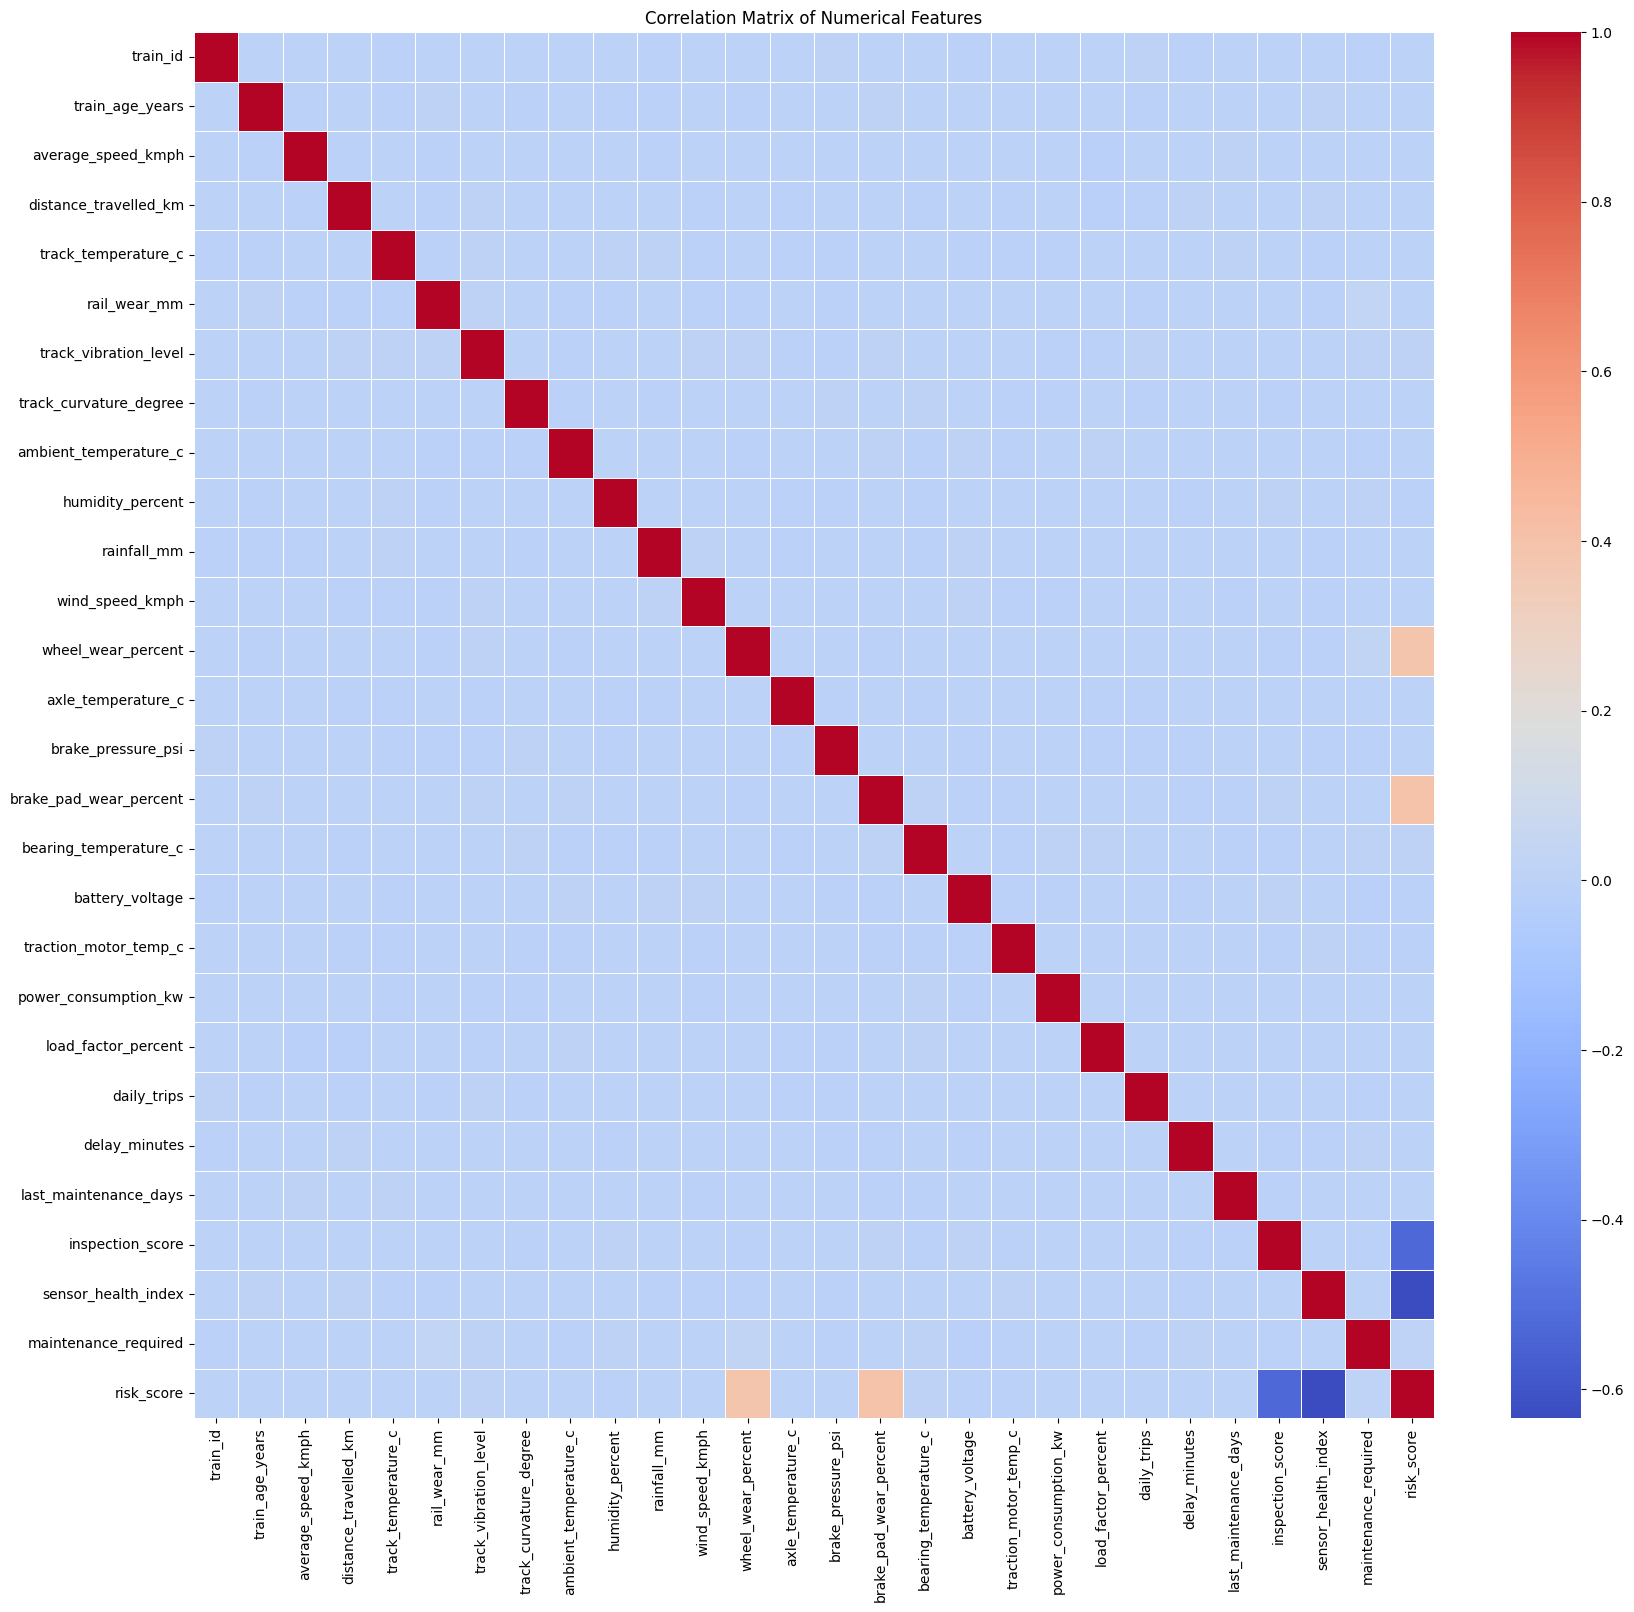

In [ ]:
# Correlation Analysis
print("Correlation Matrix of Numerical Features\n")

# Calculate the correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


**Explanation
Correlation Matrix of Numerical Features**
1. This heatmap shows the relationship (correlation) between all numerical variables in the railway dataset.
2. The dark red color (value = 1) on the diagonal means every variable is perfectly correlated with itself.
3. Light blue or white colors indicate little or no correlation between two variables.
4. Orange shades represent a positive correlation, meaning both variables tend to increase together.
5. Dark blue shades represent a negative correlation, meaning when one variable increases, the other tends to decrease.
6. Most features in this dataset have very weak correlations, indicating they are largely independent.
7. The risk_score has a positive correlation with features like wheel_wear_percent and brake_pad_wear_percent, suggesting that higher wear increases the risk score.
8. The risk_score has a negative correlation with inspection_score and sensor_health_index, meaning better inspections and healthier sensors reduce risk.
9. Since there are no strong correlations among most variables, multicollinearity is low, which is beneficial for machine learning models.
10. Overall, the correlation matrix helps identify which features are most related to equipment risk and supports better predictive maintenance decisions.

**Summary**
The Exploratory Data Analysis provides a clear understanding of the railway predictive maintenance dataset. Descriptive statistics summarize the characteristics of numerical variables, while distribution plots reveal the frequency and spread of both numerical and categorical features. The correlation matrix reveals that most numerical features have weak relationships with each other. However, wear-related features positively influence the risk score, while inspection score and sensor health index negatively influence it, making them important variables for predictive maintenance analysis.

In [ ]:
# 4. Data Visualization

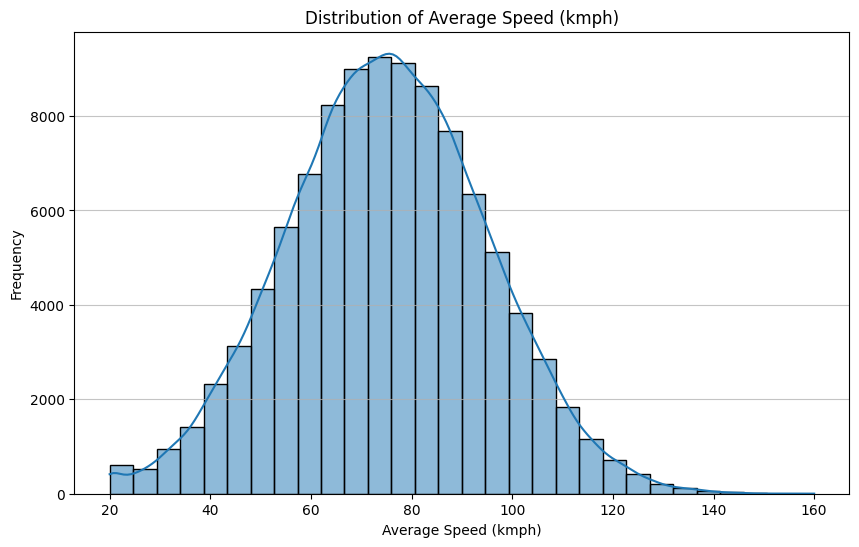

In [ ]:
# Visualization 1: Distribution of `average_speed_kmph`
plt.figure(figsize=(10, 6))
sns.histplot(df['average_speed_kmph'], kde=True, bins=30)
plt.title('Distribution of Average Speed (kmph)')
plt.xlabel('Average Speed (kmph)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

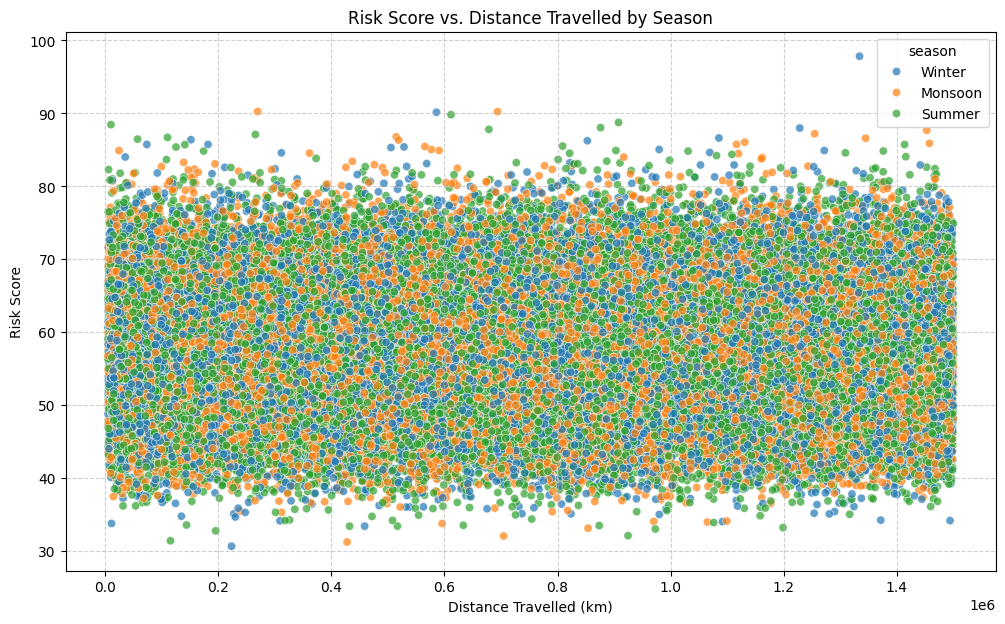

In [ ]:
# Visualization 2: `risk_score` vs. `distance_travelled_km` (Scatter Plot)
plt.figure(figsize=(12, 7))
sns.scatterplot(x='distance_travelled_km', y='risk_score', hue='season', data=df, alpha=0.7)
plt.title('Risk Score vs. Distance Travelled by Season')
plt.xlabel('Distance Travelled (km)')
plt.ylabel('Risk Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

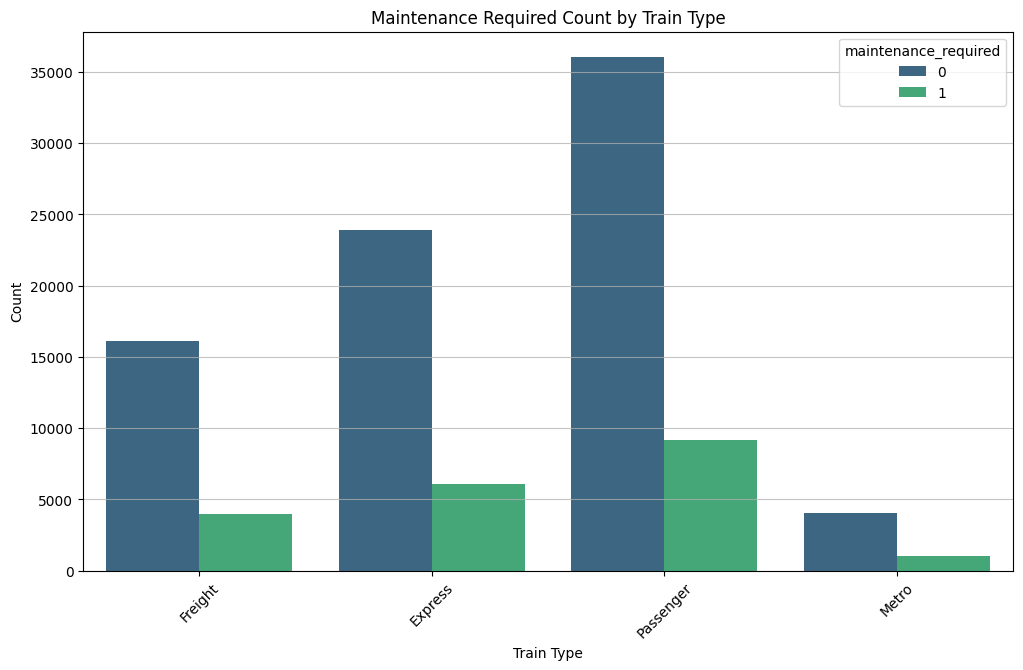

In [ ]:
# Visualization 3: `maintenance_required` by `train_type` (Bar Plot)
plt.figure(figsize=(12, 7))
sns.countplot(x='train_type', hue='maintenance_required', data=df, palette='viridis')
plt.title('Maintenance Required Count by Train Type')
plt.xlabel('Train Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

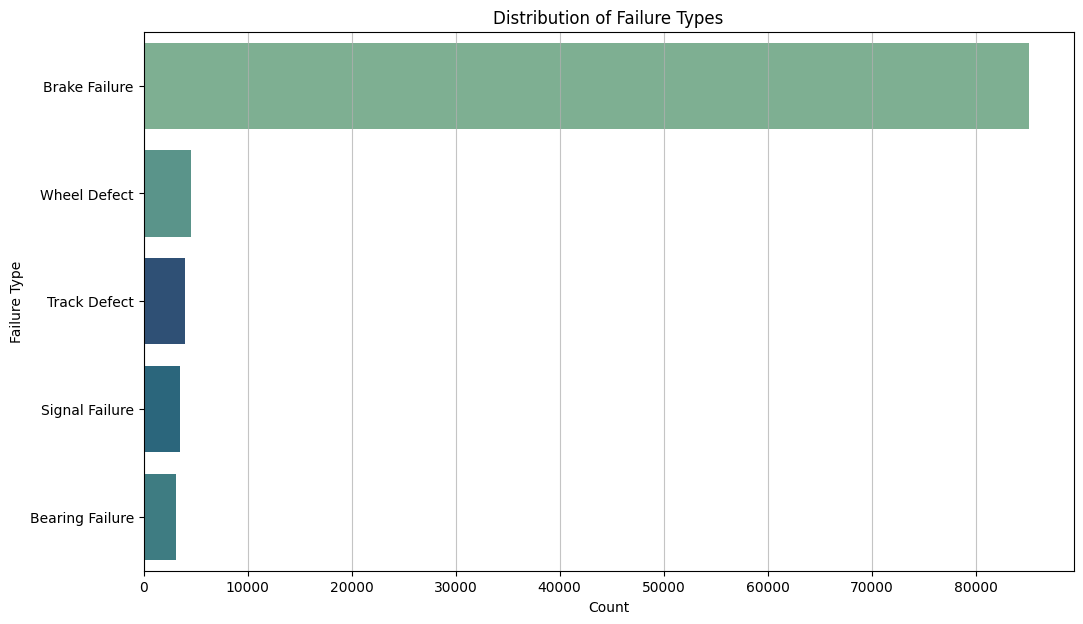

In [ ]:
# Visualization 4: Distribution of Failure Types (Count Plot)
plt.figure(figsize=(12, 7))
sns.countplot(y='failure_type', data=df, hue='failure_type', order=df['failure_type'].value_counts().index, palette='crest', legend=False)
plt.title('Distribution of Failure Types')
plt.xlabel('Count')
plt.ylabel('Failure Type')
plt.grid(axis='x', alpha=0.75)
plt.show()

**Summary:-** Overall, the visualizations indicate that the dataset is well-structured and provides meaningful insights into railway operations and maintenance. They reveal important trends in train speed, maintenance requirements, risk levels, and equipment failures. These findings support data-driven decision-making, allowing railway authorities to improve preventive maintenance planning, optimize resource allocation, minimize operational disruptions, and enhance the safety and reliability of the Indian Railway system.

In [ ]:
# 5. Findings

1. Average train speeds are concentrated within a normal operating range. The histogram of average speed (kmph) indicates that most trains operate within a moderate speed range. Extremely high or low speeds occur less frequently, suggesting that railway operations generally follow standard speed limits.
2. Distance travelled has some influence on maintenance risk. The scatter plot of risk score vs. distance travelled shows that trains covering longer distances may experience slightly higher risk scores. Although the relationship is not perfectly linear, increased travel distance can contribute to greater wear and tear, leading to higher maintenance requirements.
3. Seasonal conditions affect operational risk. By categorizing the scatter plot according to season, it is evident that maintenance risk exists across all seasons. Seasonal environmental factors such as rainfall, temperature, and humidity may influence equipment performance and should be considered while planning maintenance activities.
4. Maintenance requirements differ across train types. The bar plot reveals that some train types require maintenance more frequently than others. This indicates that maintenance demand depends on factors such as train usage, operational load, and component wear, helping railway authorities prioritize maintenance schedules for specific train categories.
5. Certain failure types occur more frequently than others. The count plot of failure types shows that some failure categories are significantly more common. Identifying these recurring failures enables maintenance teams to focus on critical components and implement preventive maintenance strategies to reduce breakdowns.
6. No strong correlation exists among most numerical variables. The correlation analysis indicates that most numerical features have weak to moderate relationships, suggesting that railway equipment performance depends on multiple factors rather than a single variable.
7. The dataset is clean and suitable for analysis. After preprocessing, the dataset contains consistent and well-organized data with no significant issues related to missing values or duplicate records, making it reliable for further analysis and predictive modeling.
8. Visualizations provide meaningful operational insights. The histogram, scatter plot, bar plot, and count plot effectively highlight operational patterns, maintenance trends, and failure distributions. These visualizations simplify data interpretation and support informed decision-making.
9. Preventive maintenance can improve railway reliability. The observed maintenance and failure patterns suggest that adopting predictive and preventive maintenance strategies can help reduce unexpected equipment failures, improve train availability, and enhance passenger safety.
10. The analysis supports data-driven maintenance planning. Overall, the exploratory analysis demonstrates that operational data can be effectively used to identify maintenance priorities, optimize resource allocation, minimize downtime, and improve the efficiency and reliability of the Indian Railway system